In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import Polygon
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Прогнозирование стоимости

## Подготовка данных

In [ ]:
import glob
# найдём и отсортируем файлы
paths = sorted(glob.glob("parsed_parts/*.parquet"))

# прочитаем каждый и склеим
gdfs = [gpd.read_parquet(p) for p in paths]
gdf = pd.concat(gdfs, ignore_index=True)
gdf2 = gdf[gdf['cadastralDistrictsCode'] == 47].copy()

In [ ]:
options_df = pd.json_normalize(gdf2['options'])

# 2) присоединяем новые колонки к исходному gdf
gdf2 = gdf2.join(options_df)

# 3) (по желанию) удаляем теперь уже ненужную колонку options
gdf2 = gdf2.drop(columns=['options'])
clean_gdf = gdf2[~gdf2['land_record_subtype'].isna()].copy()
clean_gdf.head()

,cadastralDistrictsCode,category,descr,externalKey,geom_data_id,label,subcategory,system_info,geometry,area,...,land_record_subtype,land_record_type,ownership_type,permitted_use_established_by_document,previously_posted,quarter_cad_number,readable_address,right_type,specified_area,status
65,47,36368,47:07:1045005:1021,47:07:1045005:1021,81706014,47:07:1045005:1021,8,"{'inserted': '2023-08-24T12:31:44.800631', 'in...","POLYGON ((3426216.973 8375272.438, 3426262.69 ...",NaN,...,Землепользование,Земельный участок,Частная,для размещения складских и офисных зданий обще...,Учтенный,47:07:1045005,"Российская Федерация, Ленинградская область, В...",None,21.0,Учтенный
66,47,36368,47:07:1018001:2714,47:07:1018001:2714,820622296,47:07:1018001:2714,8,"{'inserted': '2025-04-18T10:56:33.010622', 'in...","POLYGON ((3430473.961 8385944.253, 3430558.155...",NaN,...,Землепользование,Земельный участок,Частная,для размещения складских и офисных зданий обще...,Учтенный,47:07:1045005,"Российская Федерация, Ленинградская область, В...",None,1223.0,Учтенный
67,47,36368,47:07:1018001:2715,47:07:1018001:2715,820622317,47:07:1018001:2715,8,"{'inserted': '2025-04-18T10:56:33.089104', 'in...","POLYGON ((3430558.155 8386031.328, 3430473.961...",NaN,...,Землепользование,Земельный участок,Частная,Для дачного строительства,Учтенный,47:07:1045005,"Ленинградская область, Всеволожский муниципаль...",Собственность,1256.0,Учтенный
68,47,36368,47:07:0000000:89982,47:07:0000000:89982,81803897,47:07:0000000:89982,8,"{'inserted': '2023-08-24T13:23:35.546798', 'in...","POLYGON ((3425522.466 8375090.826, 3425510.614...",NaN,...,Землепользование,Земельный участок,Частная,Для дачного строительства,Учтенный,47:07:1045005,"Ленинградская область, Всеволожский муниципаль...",Собственность,978.0,Учтенный
69,47,36368,47:07:1045005:785,47:07:1045005:785,81677005,47:07:1045005:785,8,"{'inserted': '2023-08-24T12:16:30.870264', 'in...","POLYGON ((3426283.242 8374758.201, 3426316.04 ...",NaN,...,Землепользование,Земельный участок,Частная,Для дачного строительства,Учтенный,47:07:1045005,"Ленинградская область, Всеволожский муниципаль...",None,1081.0,Учтенный


In [ ]:
t = clean_gdf.iloc[0]
t

cadastralDistrictsCode                                                                  47
category                                                                             36368
descr                                                                   47:07:1045005:1021
externalKey                                                             47:07:1045005:1021
geom_data_id                                                                      81706014
label                                                                   47:07:1045005:1021
subcategory                                                                              8
system_info                              {'inserted': '2023-08-24T12:31:44.800631', 'in...
geometry                                 POLYGON ((3426216.97346246 8375272.43838189, 3...
area                                                                                   NaN
cad_num                                                                 47:07:1045005:2277

In [ ]:
cols = ['cadastralDistrictsCode', 'readable_address', 'cost_value', 'cost_index', 'land_record_category_type','permitted_use_established_by_document', 'specified_area', 'geometry']

# 2. Сделайте срез и скопируйте его
new_gdf = clean_gdf[cols].copy()
new_gdf

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry
65,47,"Российская Федерация, Ленинградская область, В...",19151.79,911.99,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,21.0,"POLYGON ((3426216.973 8375272.438, 3426262.69 ..."
66,47,"Российская Федерация, Ленинградская область, В...",1096407.27,896.49,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,1223.0,"POLYGON ((3430473.961 8385944.253, 3430558.155..."
67,47,"Ленинградская область, Всеволожский муниципаль...",2064889.12,1644.02,Земли сельскохозяйственного назначения,Для дачного строительства,1256.0,"POLYGON ((3430558.155 8386031.328, 3430473.961..."
68,47,"Ленинградская область, Всеволожский муниципаль...",1675206.42,1712.89,Земли сельскохозяйственного назначения,Для дачного строительства,978.0,"POLYGON ((3425522.466 8375090.826, 3425510.614..."
69,47,"Ленинградская область, Всеволожский муниципаль...",1821355.28,1684.88,Земли сельскохозяйственного назначения,Для дачного строительства,1081.0,"POLYGON ((3426283.242 8374758.201, 3426316.04 ..."
...,...,...,...,...,...,...,...,...
961255,47,"Ленинградская область, Кингисеппский муниципал...",0.00,0.00,,,69.0,"POLYGON ((3185515.378 8312235.386, 3185581.809..."
961256,47,"Ленинградская область, Кингисеппский муниципал...",6641198.52,1818.51,Земли населенных пунктов,многоэтажная жилая застройка,3652.0,"POLYGON ((3185252.068 8311526.521, 3185194.178..."
961257,47,"Ленинградская область, Кингисеппский муниципа...",11147008.65,1642.89,Земли населенных пунктов,многоэтажная жилая застройка,6785.0,"POLYGON ((3185033.041 8312166.37, 3185053.694 ..."
961258,47,"Ленинградская область, Кингисеппский муниципал...",12177720.92,1614.44,Земли населенных пунктов,многоэтажная жилая застройка,7543.0,"POLYGON ((3185258.163 8311768.156, 3185296.069..."


In [ ]:
# 1. задаём шаблон: всё, что перед запятой и оканчивается на "муниципальный район"
pattern = r'([^,]*?муниципальный район)'

# 2. извлекаем совпадения в новую колонку
new_gdf['municipal_district'] = new_gdf['readable_address'] \
    .str.extract(pattern, expand=False) \
    .str.strip()

# 3. (опционально) при необходимости заменяем пропуски на пустую строку
new_gdf['municipal_district'] = new_gdf['municipal_district'].fillna('')
new_gdf

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,municipal_district
65,47,"Российская Федерация, Ленинградская область, В...",19151.79,911.99,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,21.0,"POLYGON ((3426216.973 8375272.438, 3426262.69 ...",Всеволожский муниципальный район
66,47,"Российская Федерация, Ленинградская область, В...",1096407.27,896.49,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,1223.0,"POLYGON ((3430473.961 8385944.253, 3430558.155...",Всеволожский муниципальный район
67,47,"Ленинградская область, Всеволожский муниципаль...",2064889.12,1644.02,Земли сельскохозяйственного назначения,Для дачного строительства,1256.0,"POLYGON ((3430558.155 8386031.328, 3430473.961...",Всеволожский муниципальный район
68,47,"Ленинградская область, Всеволожский муниципаль...",1675206.42,1712.89,Земли сельскохозяйственного назначения,Для дачного строительства,978.0,"POLYGON ((3425522.466 8375090.826, 3425510.614...",Всеволожский муниципальный район
69,47,"Ленинградская область, Всеволожский муниципаль...",1821355.28,1684.88,Земли сельскохозяйственного назначения,Для дачного строительства,1081.0,"POLYGON ((3426283.242 8374758.201, 3426316.04 ...",Всеволожский муниципальный район
...,...,...,...,...,...,...,...,...,...
961255,47,"Ленинградская область, Кингисеппский муниципал...",0.00,0.00,,,69.0,"POLYGON ((3185515.378 8312235.386, 3185581.809...",Кингисеппский муниципальный район
961256,47,"Ленинградская область, Кингисеппский муниципал...",6641198.52,1818.51,Земли населенных пунктов,многоэтажная жилая застройка,3652.0,"POLYGON ((3185252.068 8311526.521, 3185194.178...",Кингисеппский муниципальный район
961257,47,"Ленинградская область, Кингисеппский муниципа...",11147008.65,1642.89,Земли населенных пунктов,многоэтажная жилая застройка,6785.0,"POLYGON ((3185033.041 8312166.37, 3185053.694 ...",Кингисеппский муниципальный район
961258,47,"Ленинградская область, Кингисеппский муниципал...",12177720.92,1614.44,Земли населенных пунктов,многоэтажная жилая застройка,7543.0,"POLYGON ((3185258.163 8311768.156, 3185296.069...",Кингисеппский муниципальный район


In [ ]:
test = gpd.read_parquet('data/blocks_indicator.parquet')
test

,id,geometry,territory_id,name,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Средняя доступность до центра федерального округа,Социальное обеспечение (базовое),Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций
0,0,"POLYGON ((570883.045 6596529.946, 570883.081 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"POLYGON ((570987.035 6596464.499, 570987.085 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,"POLYGON ((572676.73 6596606.982, 572676.701 65...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,"POLYGON ((583242.895 6595451.954, 583243.013 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,"POLYGON ((582405.498 6595459.455, 582405.614 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34642,34645,"POLYGON ((279466.739 6647657.982, 279466.837 6...",1267.0,город Сосновый бор,63462.0,66.50,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.0,0.0,0.0,5.0,1.0,0.0
34643,34646,"POLYGON ((279467.148 6647660.126, 279467.165 6...",1267.0,город Сосновый бор,63462.0,66.50,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.0,0.0,0.0,5.0,1.0,0.0
34644,34647,"POLYGON ((279542.296 6648001.072, 279542.336 6...",1267.0,город Сосновый бор,63462.0,66.50,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.0,0.0,0.0,5.0,1.0,0.0
34645,34648,"POLYGON ((279625.847 6648207.164, 279625.886 6...",1267.0,город Сосновый бор,63462.0,66.50,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,6.0,0.0,0.0,5.0,1.0,0.0


In [ ]:
threshold_columns = [
    col for col in test.columns
    if (test[col] == 0).sum() < len(test) / 2
]
print(threshold_columns)

['id', 'geometry', 'territory_id', 'name', 'Численность населения', 'Степень урбанизации территории', 'Средняя доступность до федеральных транспортных магистралей', 'Средняя доступность до центра региона', 'Связанность', 'Связанность населенных пунктов', 'Плотность улично-дорожной сети', 'Протяженность дорог федерального значения', 'Протяженность дорог регионального значения', 'Протяженность дорог местного значения', 'Количество остановок общественного транспорта', 'Количество автозаправочных станций', 'Средняя доступность  автозаправочных станций', 'Количество остановок железнодорожного транспорта', 'Средняя доступность остановок железнодорожного транспорта', 'Средняя доступность международных аэропортов', 'Средняя доступность аэропортов местного значения', 'Обеспеченность детскими садами', 'Обеспеченность школами', 'Обеспеченность центрами детского творчества', 'Обеспеченность ФАП / амбулаториями', 'Обеспеченность аптеками', 'Обеспеченность поликлиниками / центрами семейной медицины'

In [ ]:
test2 = test[threshold_columns].copy()
test2.fillna(0, inplace=True)
test2.head()

,id,geometry,territory_id,name,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Средняя доступность до центра федерального округа,Социальное обеспечение (базовое),Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций
0,0,"POLYGON ((570883.045 6596529.946, 570883.081 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,"POLYGON ((570987.035 6596464.499, 570987.085 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,"POLYGON ((572676.73 6596606.982, 572676.701 65...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3,"POLYGON ((583242.895 6595451.954, 583243.013 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4,"POLYGON ((582405.498 6595459.455, 582405.614 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import geopandas as gpd

# 1. Убедимся, что оба GDF в одной CRS
new_gdf = new_gdf.to_crs(test2.crs)

# 2. Список полей, которые нужно перенести
attrs = [
    'Численность населения',
    'Степень урбанизации территории',
    'Средняя доступность до федеральных транспортных магистралей',
    'Средняя доступность до центра региона',
    'Связанность',
    'Связанность населенных пунктов',
    'Плотность улично-дорожной сети',
    'Протяженность дорог федерального значения',
    'Протяженность дорог регионального значения',
    'Протяженность дорог местного значения',
    'Количество остановок общественного транспорта',
    'Количество автозаправочных станций',
    'Средняя доступность  автозаправочных станций',
    'Количество остановок железнодорожного транспорта',
    'Средняя доступность остановок железнодорожного транспорта',
    'Средняя доступность международных аэропортов',
    'Средняя доступность аэропортов местного значения',
    'Обеспеченность детскими садами',
    'Обеспеченность школами',
    'Обеспеченность центрами детского творчества',
    'Обеспеченность ФАП / амбулаториями',
    'Обеспеченность аптеками',
    'Обеспеченность поликлиниками / центрами семейной медицины',
    'Обеспеченность участковыми больницами',
    'Обеспеченность городскими больницами (д/в)',
    'Обеспеченность коммерческими клиниками',
    'Обеспеченность продуктовыми магазинами',
    'Обеспеченность ТЦ / супермаркетами',
    'Обеспеченность зоомагазинами',
    'Обеспеченность ТРК / гипермаркетами',
    'Обеспеченность кафе / кофейнями',
    'Обеспеченность барами / ресторанами',
    'Обеспеченность комьюнити-центрами / домами культуры',
    'Обеспеченность медиатеками / библиотеками',
    'Обеспеченность культовыми объектами',
    'Обеспеченность детскими площадками',
    'Обеспеченность скверами / бульварами / лесопарками',
    'Обеспеченность парками',
    'Обеспеченность воркаутами / школьными спортзалами',
    'Обеспеченность спортзалами ОП / фитнес-центрами',
    'Обеспеченность ФОК / бассейнами',
    'Обеспеченность пунктами доставки / почтовыми отделениями',
    'Обеспеченность парикмахерскими / салонами красоты',
    'Обеспеченность отделениями банков',
    'Обеспеченность остановками ОТ',
    'Обеспеченность парковками',
    'Обеспеченность автозаправками',
    'Обеспеченность ЖД станциями',
    'Обеспеченность автосалонами / автосервисами',
    'Обеспеченность участковыми пунктами полиции',
    'Обеспеченность опорными пунктами полиции',
    'Обеспеченность пожарными депо',
    'Связанность общественным транспортом',
    'Средняя доступность до федерального центра',
    'Средняя доступность до центра федерального округа',
    'Социальное обеспечение (базовое)',
    'Социальное обеспечение (базовое+)',
    'Социальное обеспечение (комфорт)',
    'Количество объектов инженерной инфраструктуры',
    'Количество электростанций (ТЭС, АЭС и пр.)',
    'Количество больших водозаборов',
    'Количество очистительных сооружений',
    'Количество крупных водохранилищ',
    'Количество газораспределительных станций'
]

# 3. Оставим из test2 только геометрию и нужные поля
test2_sel = test2[['geometry'] + attrs]

# 4. Пространственный join: для каждого объекта gdf_new найдутся все
#    пересекающиеся объекты test2 и их атрибуты «пришиваются»
joined = gpd.sjoin(
    new_gdf,
    test2_sel,
    how='left',            # если нет пересечений, атрибуты будут NaN
    predicate='intersects' # можно also 'within', 'contains' и т.п.
)

# 5. Уберём служебное поле index_right и, если нужно, столбец geometry_right
joined = joined.drop(columns=['index_right'])

# Если geometry из test2 тоже попала, можно её удалить:
if 'geometry_right' in joined.columns:
    joined = joined.drop(columns=['geometry_right'])


joined = (
    joined
    .groupby(joined.index)
    .agg({col: 'first' for col in attrs})
    .join(new_gdf.geometry)  # подцепляем обратно геометрию
    .set_geometry('geometry')
)

joined.gpd_to_parquet('data/cadastr_indicator.parquet', index=False)

In [ ]:
# joined.to_parquet('data/cadastr_indicator.parquet', index=False)

## Подготовка даных 2

In [3]:
import glob
# найдём и отсортируем файлы
paths = sorted(glob.glob("parsed_parts/*.parquet"))

# прочитаем каждый и склеим
gdfs = [gpd.read_parquet(p) for p in paths]
gdf = pd.concat(gdfs, ignore_index=True)
gdf2 = gdf[gdf['cadastralDistrictsCode'] == 47].copy()

In [4]:
options_df = pd.json_normalize(gdf2['options'])

# 2) присоединяем новые колонки к исходному gdf
gdf2 = gdf2.join(options_df)

# 3) (по желанию) удаляем теперь уже ненужную колонку options
gdf2 = gdf2.drop(columns=['options'])
clean_gdf = gdf2[~gdf2['land_record_subtype'].isna()].copy()
clean_gdf.head()

,cadastralDistrictsCode,category,descr,externalKey,geom_data_id,label,subcategory,system_info,geometry,area,...,land_record_subtype,land_record_type,ownership_type,permitted_use_established_by_document,previously_posted,quarter_cad_number,readable_address,right_type,specified_area,status
65,47,36368,47:07:1045005:1021,47:07:1045005:1021,81706014,47:07:1045005:1021,8,"{'inserted': '2023-08-24T12:31:44.800631', 'in...","POLYGON ((3426216.973 8375272.438, 3426262.69 ...",NaN,...,Землепользование,Земельный участок,Частная,для размещения складских и офисных зданий обще...,Учтенный,47:07:1045005,"Российская Федерация, Ленинградская область, В...",None,21.0,Учтенный
66,47,36368,47:07:1018001:2714,47:07:1018001:2714,820622296,47:07:1018001:2714,8,"{'inserted': '2025-04-18T10:56:33.010622', 'in...","POLYGON ((3430473.961 8385944.253, 3430558.155...",NaN,...,Землепользование,Земельный участок,Частная,для размещения складских и офисных зданий обще...,Учтенный,47:07:1045005,"Российская Федерация, Ленинградская область, В...",None,1223.0,Учтенный
67,47,36368,47:07:1018001:2715,47:07:1018001:2715,820622317,47:07:1018001:2715,8,"{'inserted': '2025-04-18T10:56:33.089104', 'in...","POLYGON ((3430558.155 8386031.328, 3430473.961...",NaN,...,Землепользование,Земельный участок,Частная,Для дачного строительства,Учтенный,47:07:1045005,"Ленинградская область, Всеволожский муниципаль...",Собственность,1256.0,Учтенный
68,47,36368,47:07:0000000:89982,47:07:0000000:89982,81803897,47:07:0000000:89982,8,"{'inserted': '2023-08-24T13:23:35.546798', 'in...","POLYGON ((3425522.466 8375090.826, 3425510.614...",NaN,...,Землепользование,Земельный участок,Частная,Для дачного строительства,Учтенный,47:07:1045005,"Ленинградская область, Всеволожский муниципаль...",Собственность,978.0,Учтенный
69,47,36368,47:07:1045005:785,47:07:1045005:785,81677005,47:07:1045005:785,8,"{'inserted': '2023-08-24T12:16:30.870264', 'in...","POLYGON ((3426283.242 8374758.201, 3426316.04 ...",NaN,...,Землепользование,Земельный участок,Частная,Для дачного строительства,Учтенный,47:07:1045005,"Ленинградская область, Всеволожский муниципаль...",None,1081.0,Учтенный


In [5]:
cols = ['cadastralDistrictsCode', 'readable_address', 'cost_value', 'cost_index', 'land_record_category_type','permitted_use_established_by_document', 'specified_area', 'geometry']

# 2. Сделайте срез и скопируйте его
new_gdf = clean_gdf[cols].copy()
new_gdf

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry
65,47,"Российская Федерация, Ленинградская область, В...",19151.79,911.99,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,21.0,"POLYGON ((3426216.973 8375272.438, 3426262.69 ..."
66,47,"Российская Федерация, Ленинградская область, В...",1096407.27,896.49,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,1223.0,"POLYGON ((3430473.961 8385944.253, 3430558.155..."
67,47,"Ленинградская область, Всеволожский муниципаль...",2064889.12,1644.02,Земли сельскохозяйственного назначения,Для дачного строительства,1256.0,"POLYGON ((3430558.155 8386031.328, 3430473.961..."
68,47,"Ленинградская область, Всеволожский муниципаль...",1675206.42,1712.89,Земли сельскохозяйственного назначения,Для дачного строительства,978.0,"POLYGON ((3425522.466 8375090.826, 3425510.614..."
69,47,"Ленинградская область, Всеволожский муниципаль...",1821355.28,1684.88,Земли сельскохозяйственного назначения,Для дачного строительства,1081.0,"POLYGON ((3426283.242 8374758.201, 3426316.04 ..."
...,...,...,...,...,...,...,...,...
961255,47,"Ленинградская область, Кингисеппский муниципал...",0.00,0.00,,,69.0,"POLYGON ((3185515.378 8312235.386, 3185581.809..."
961256,47,"Ленинградская область, Кингисеппский муниципал...",6641198.52,1818.51,Земли населенных пунктов,многоэтажная жилая застройка,3652.0,"POLYGON ((3185252.068 8311526.521, 3185194.178..."
961257,47,"Ленинградская область, Кингисеппский муниципа...",11147008.65,1642.89,Земли населенных пунктов,многоэтажная жилая застройка,6785.0,"POLYGON ((3185033.041 8312166.37, 3185053.694 ..."
961258,47,"Ленинградская область, Кингисеппский муниципал...",12177720.92,1614.44,Земли населенных пунктов,многоэтажная жилая застройка,7543.0,"POLYGON ((3185258.163 8311768.156, 3185296.069..."


In [6]:
# 1. задаём шаблон: всё, что перед запятой и оканчивается на "муниципальный район"
pattern = r'([^,]*?муниципальный район)'

# 2. извлекаем совпадения в новую колонку
new_gdf['municipal_district'] = new_gdf['readable_address'] \
    .str.extract(pattern, expand=False) \
    .str.strip()

# 3. (опционально) при необходимости заменяем пропуски на пустую строку
new_gdf['municipal_district'] = new_gdf['municipal_district'].fillna('')
new_gdf

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,municipal_district
65,47,"Российская Федерация, Ленинградская область, В...",19151.79,911.99,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,21.0,"POLYGON ((3426216.973 8375272.438, 3426262.69 ...",Всеволожский муниципальный район
66,47,"Российская Федерация, Ленинградская область, В...",1096407.27,896.49,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,1223.0,"POLYGON ((3430473.961 8385944.253, 3430558.155...",Всеволожский муниципальный район
67,47,"Ленинградская область, Всеволожский муниципаль...",2064889.12,1644.02,Земли сельскохозяйственного назначения,Для дачного строительства,1256.0,"POLYGON ((3430558.155 8386031.328, 3430473.961...",Всеволожский муниципальный район
68,47,"Ленинградская область, Всеволожский муниципаль...",1675206.42,1712.89,Земли сельскохозяйственного назначения,Для дачного строительства,978.0,"POLYGON ((3425522.466 8375090.826, 3425510.614...",Всеволожский муниципальный район
69,47,"Ленинградская область, Всеволожский муниципаль...",1821355.28,1684.88,Земли сельскохозяйственного назначения,Для дачного строительства,1081.0,"POLYGON ((3426283.242 8374758.201, 3426316.04 ...",Всеволожский муниципальный район
...,...,...,...,...,...,...,...,...,...
961255,47,"Ленинградская область, Кингисеппский муниципал...",0.00,0.00,,,69.0,"POLYGON ((3185515.378 8312235.386, 3185581.809...",Кингисеппский муниципальный район
961256,47,"Ленинградская область, Кингисеппский муниципал...",6641198.52,1818.51,Земли населенных пунктов,многоэтажная жилая застройка,3652.0,"POLYGON ((3185252.068 8311526.521, 3185194.178...",Кингисеппский муниципальный район
961257,47,"Ленинградская область, Кингисеппский муниципа...",11147008.65,1642.89,Земли населенных пунктов,многоэтажная жилая застройка,6785.0,"POLYGON ((3185033.041 8312166.37, 3185053.694 ...",Кингисеппский муниципальный район
961258,47,"Ленинградская область, Кингисеппский муниципал...",12177720.92,1614.44,Земли населенных пунктов,многоэтажная жилая застройка,7543.0,"POLYGON ((3185258.163 8311768.156, 3185296.069...",Кингисеппский муниципальный район


In [8]:
#Считаем на сколько территория удобная для зонирования 

def rectangle_likeness_rotated(geom):
    if geom is None or geom.is_empty:
        return np.nan
    area = geom.area
    rotated_rect = geom.minimum_rotated_rectangle
    bbox_area = rotated_rect.area
    if bbox_area == 0:
        return np.nan
    return area / bbox_area  # ближе к 1 — ближе к повёрнутому прямоугольнику

# Добавим в GeoDataFrame
new_gdf['rectangle_score'] = new_gdf['geometry'].apply(rectangle_likeness_rotated).round(2)
new_gdf

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,municipal_district,rectangle_score
65,47,"Российская Федерация, Ленинградская область, В...",19151.79,911.99,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,21.0,"POLYGON ((3426216.973 8375272.438, 3426262.69 ...",Всеволожский муниципальный район,0.46
66,47,"Российская Федерация, Ленинградская область, В...",1096407.27,896.49,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,1223.0,"POLYGON ((3430473.961 8385944.253, 3430558.155...",Всеволожский муниципальный район,0.90
67,47,"Ленинградская область, Всеволожский муниципаль...",2064889.12,1644.02,Земли сельскохозяйственного назначения,Для дачного строительства,1256.0,"POLYGON ((3430558.155 8386031.328, 3430473.961...",Всеволожский муниципальный район,0.85
68,47,"Ленинградская область, Всеволожский муниципаль...",1675206.42,1712.89,Земли сельскохозяйственного назначения,Для дачного строительства,978.0,"POLYGON ((3425522.466 8375090.826, 3425510.614...",Всеволожский муниципальный район,0.95
69,47,"Ленинградская область, Всеволожский муниципаль...",1821355.28,1684.88,Земли сельскохозяйственного назначения,Для дачного строительства,1081.0,"POLYGON ((3426283.242 8374758.201, 3426316.04 ...",Всеволожский муниципальный район,0.50
...,...,...,...,...,...,...,...,...,...,...
961255,47,"Ленинградская область, Кингисеппский муниципал...",0.00,0.00,,,69.0,"POLYGON ((3185515.378 8312235.386, 3185581.809...",Кингисеппский муниципальный район,0.98
961256,47,"Ленинградская область, Кингисеппский муниципал...",6641198.52,1818.51,Земли населенных пунктов,многоэтажная жилая застройка,3652.0,"POLYGON ((3185252.068 8311526.521, 3185194.178...",Кингисеппский муниципальный район,0.74
961257,47,"Ленинградская область, Кингисеппский муниципа...",11147008.65,1642.89,Земли населенных пунктов,многоэтажная жилая застройка,6785.0,"POLYGON ((3185033.041 8312166.37, 3185053.694 ...",Кингисеппский муниципальный район,0.64
961258,47,"Ленинградская область, Кингисеппский муниципал...",12177720.92,1614.44,Земли населенных пунктов,многоэтажная жилая застройка,7543.0,"POLYGON ((3185258.163 8311768.156, 3185296.069...",Кингисеппский муниципальный район,0.98


In [9]:
# 1. Устанавливаем необходимые библиотеки
# pip install geopandas osmnx

import osmnx as ox
import geopandas as gpd

# 2. Загружаем границы Санкт-Петербурга из OpenStreetMap
#    Получим GeoDataFrame с одним полигоном (границы города)
gdf_city = ox.geocode_to_gdf("Saint Petersburg, Russia")

# 3. Переводим обе GeoDataFrame в метрическую проекцию (Web Mercator)
gdf_city = gdf_city.to_crs(epsg=3857)
new_gdf = new_gdf.to_crs(epsg=3857)  # ваш исходный GeoDataFrame с полигонами

# 4. Находим центроид границ города
city_centroid = gdf_city.geometry.centroid.iloc[0]

# 5. Вычисляем расстояние от каждого полигона до этого центроида
#    Здесь берём центр каждого полигона (или сами полигоны, но обычно centroid)
new_gdf["dist_to_spb_m"] = (
    new_gdf.geometry.centroid  # можно заменить на .representative_point(), если нужно
    .distance(city_centroid)
)

# 6. Результат: в столбце dist_to_spb_m — расстояние в метрах
new_gdf

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,municipal_district,rectangle_score,dist_to_spb_m
65,47,"Российская Федерация, Ленинградская область, В...",19151.79,911.99,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,21.0,"POLYGON ((3426216.973 8375272.438, 3426262.69 ...",Всеволожский муниципальный район,0.46,80973.894084
66,47,"Российская Федерация, Ленинградская область, В...",1096407.27,896.49,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,1223.0,"POLYGON ((3430473.961 8385944.253, 3430558.155...",Всеволожский муниципальный район,0.90,83636.805241
67,47,"Ленинградская область, Всеволожский муниципаль...",2064889.12,1644.02,Земли сельскохозяйственного назначения,Для дачного строительства,1256.0,"POLYGON ((3430558.155 8386031.328, 3430473.961...",Всеволожский муниципальный район,0.85,83675.273645
68,47,"Ленинградская область, Всеволожский муниципаль...",1675206.42,1712.89,Земли сельскохозяйственного назначения,Для дачного строительства,978.0,"POLYGON ((3425522.466 8375090.826, 3425510.614...",Всеволожский муниципальный район,0.95,80224.247799
69,47,"Ленинградская область, Всеволожский муниципаль...",1821355.28,1684.88,Земли сельскохозяйственного назначения,Для дачного строительства,1081.0,"POLYGON ((3426283.242 8374758.201, 3426316.04 ...",Всеволожский муниципальный район,0.50,80951.648891
...,...,...,...,...,...,...,...,...,...,...,...
961255,47,"Ленинградская область, Кингисеппский муниципал...",0.00,0.00,,,69.0,"POLYGON ((3185515.378 8312235.386, 3185581.809...",Кингисеппский муниципальный район,0.98,179958.967502
961256,47,"Ленинградская область, Кингисеппский муниципал...",6641198.52,1818.51,Земли населенных пунктов,многоэтажная жилая застройка,3652.0,"POLYGON ((3185252.068 8311526.521, 3185194.178...",Кингисеппский муниципальный район,0.74,180584.296544
961257,47,"Ленинградская область, Кингисеппский муниципа...",11147008.65,1642.89,Земли населенных пунктов,многоэтажная жилая застройка,6785.0,"POLYGON ((3185033.041 8312166.37, 3185053.694 ...",Кингисеппский муниципальный район,0.64,180400.921844
961258,47,"Ленинградская область, Кингисеппский муниципал...",12177720.92,1614.44,Земли населенных пунктов,многоэтажная жилая застройка,7543.0,"POLYGON ((3185258.163 8311768.156, 3185296.069...",Кингисеппский муниципальный район,0.98,180376.164628


In [15]:
filtered_gdf = new_gdf[new_gdf['municipal_district'] == 'Выборгский муниципальный район']
filtered_gdf.head(2)

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,municipal_district,rectangle_score,dist_to_spb_m
26805,47,"Российская Федерация, Ленинградская область, В...",276540.0,230.45,Земли населенных пунктов,под существующий жилой дом,1200.0,"POLYGON ((3421557.499 8370382.687, 3421556.696...",Выборгский муниципальный район,0.94,77448.089184
26806,47,"Российская Федерация, Ленинградская область, В...",561568.0,200.56,Земли населенных пунктов,для ведения личного подсобного хозяйства,2800.0,"POLYGON ((3421396.302 8370348.128, 3421435.959...",Выборгский муниципальный район,0.96,77365.434781


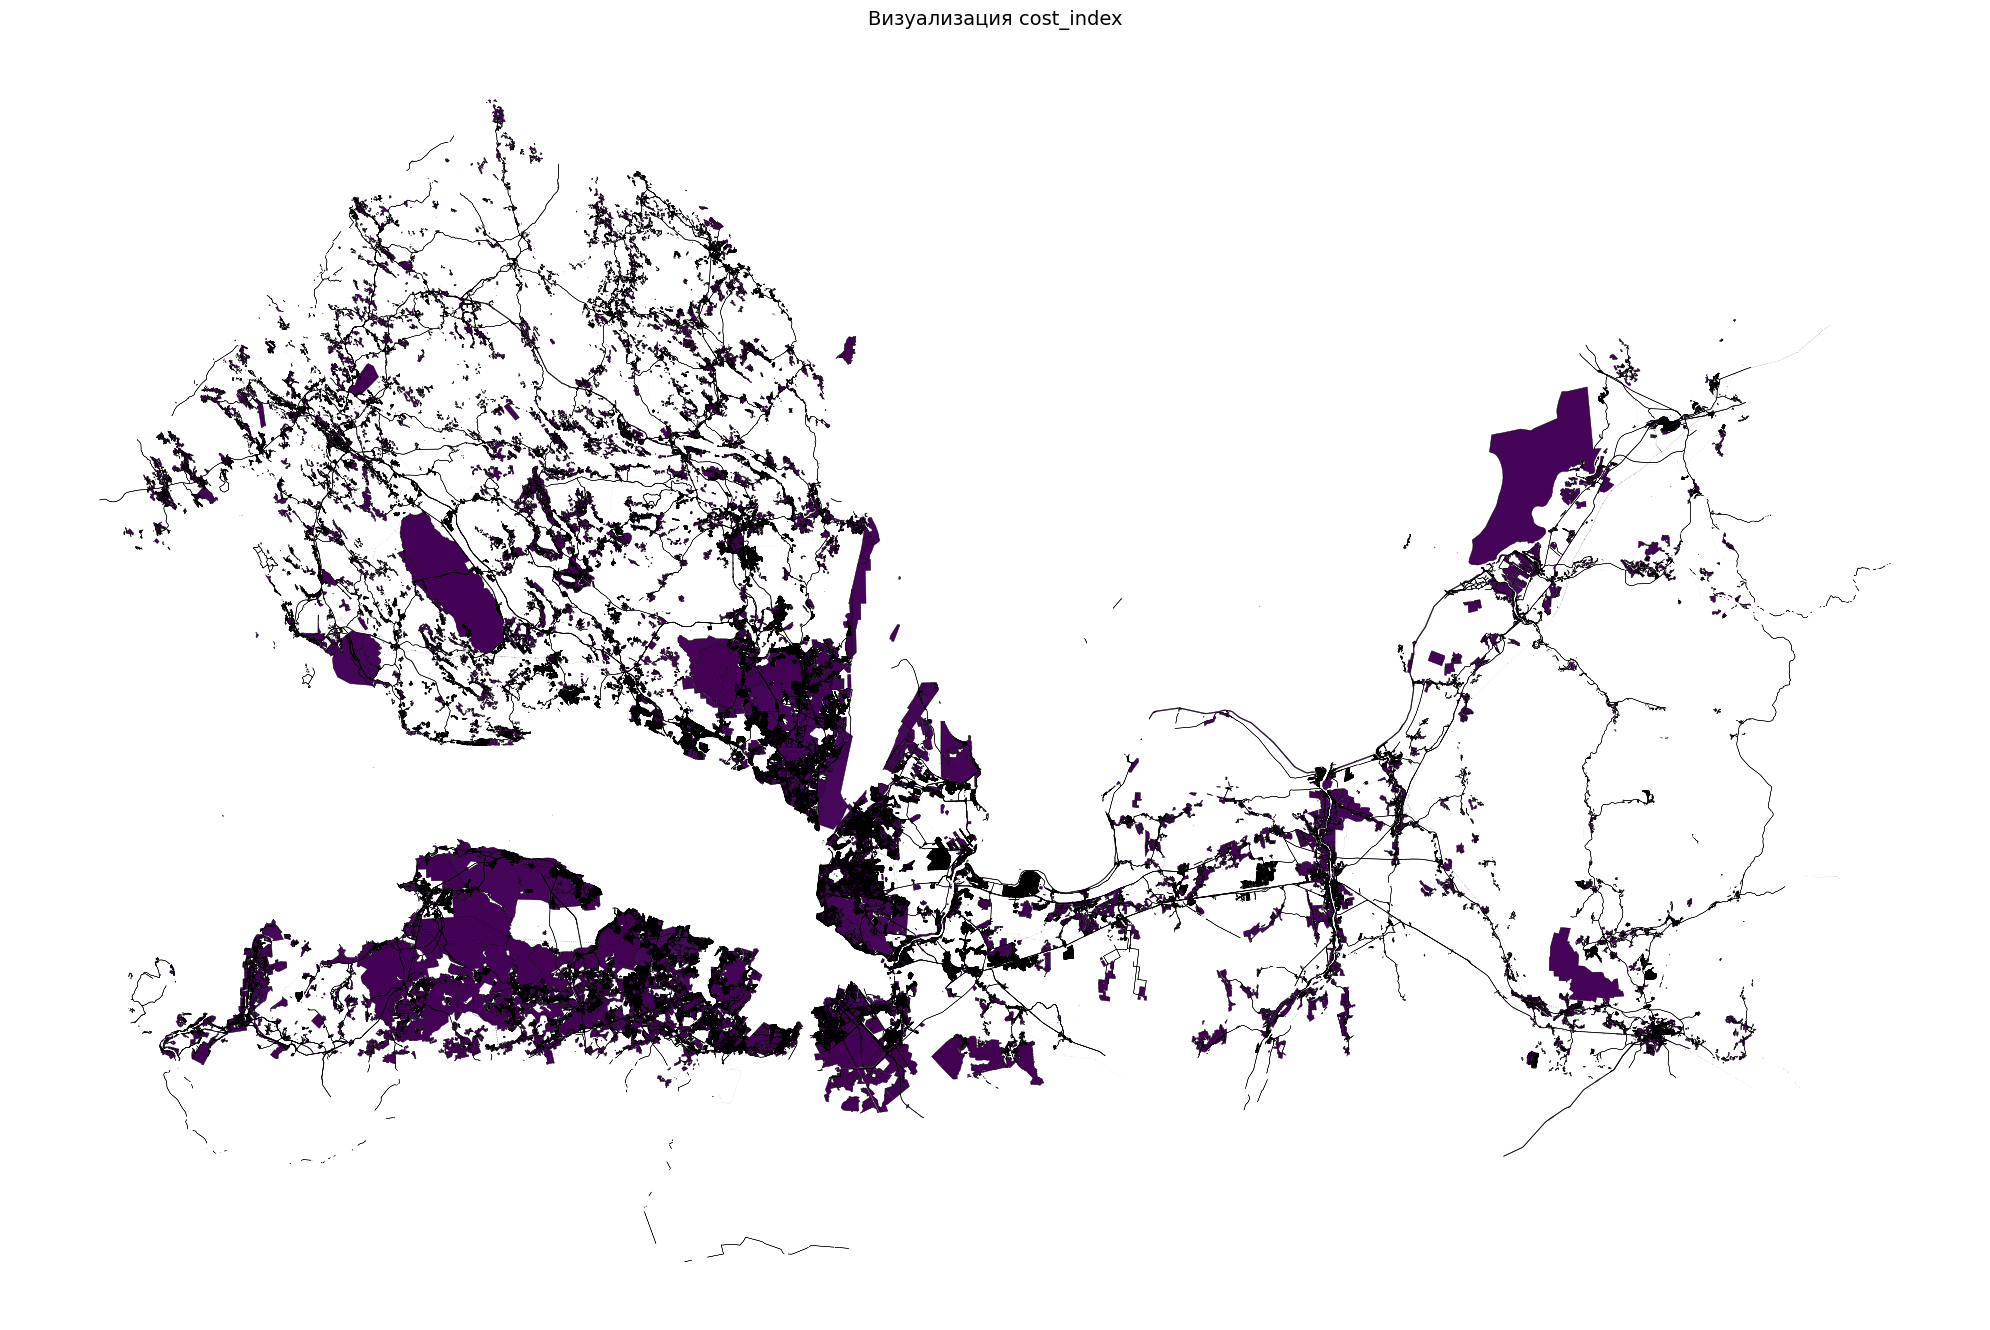

In [18]:
import matplotlib.pyplot as plt

# Если ещё не установлены дополнительные стили визуализации (необязательно):
# %matplotlib inline

fig, ax = plt.subplots(figsize=(20, 20))

new_gdf.plot(
    column='cost_index',       # Атрибут, по которому окрашиваем
    ax=ax,
    cmap='viridis',            # Палитра цветов (можно поменять на любую из Matplotlib)
    legend=False,               # Показываем легенду
    edgecolor='black',         # Цвет границ полигонов
    linewidth=0.3              # Толщина границ
)

ax.set_title('Визуализация cost_index', fontsize=14, pad=12)
ax.set_axis_off()  # Убираем оси (по желанию)

plt.tight_layout()
plt.show()


In [ ]:
# new_gdf.to_parquet('data/cadastr_indicator2.parquet', index=False)

## Машинное обучение (данные 1)

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import Polygon
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [5]:
cadastr = gpd.read_parquet('data/cadastr_indicator.parquet')
cadastr = cadastr.reset_index(drop=True)  # сбрасываем индекс, не сохраняя его
cadastr['id'] = cadastr.index    
cadastr

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,municipal_district,Численность населения,...,Социальное обеспечение (базовое),Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций,id
0,47,"Российская Федерация, Ленинградская область, В...",19151.79,911.99,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,21.0,"POLYGON ((375678.902 6641238.478, 375701.982 6...",Всеволожский муниципальный район,28766.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,47,"Российская Федерация, Ленинградская область, В...",1096407.27,896.49,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,1223.0,"POLYGON ((377994.708 6646517.392, 378038.398 6...",Всеволожский муниципальный район,28766.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,47,"Ленинградская область, Всеволожский муниципаль...",2064889.12,1644.02,Земли сельскохозяйственного назначения,Для дачного строительства,1256.0,"POLYGON ((378038.398 6646559.62, 377994.708 66...",Всеволожский муниципальный район,28766.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,47,"Ленинградская область, Всеволожский муниципаль...",1675206.42,1712.89,Земли сельскохозяйственного назначения,Для дачного строительства,978.0,"POLYGON ((375326.821 6641159.094, 375319.503 6...",Всеволожский муниципальный район,28766.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,47,"Ленинградская область, Всеволожский муниципаль...",1821355.28,1684.88,Земли сельскохозяйственного назначения,Для дачного строительства,1081.0,"POLYGON ((375703.548 6640979.366, 375719.825 6...",Всеволожский муниципальный район,28766.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902420,47,"Ленинградская область, Кингисеппский муниципал...",0.00,0.00,,,69.0,"POLYGON ((252675.191 6615549.241, 252706.947 6...",Кингисеппский муниципальный район,3414.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,902420
902421,47,"Ленинградская область, Кингисеппский муниципал...",6641198.52,1818.51,Земли населенных пунктов,многоэтажная жилая застройка,3652.0,"POLYGON ((252518.171 6615199.762, 252490.279 6...",Кингисеппский муниципальный район,3414.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,902421
902422,47,"Ленинградская область, Кингисеппский муниципа...",11147008.65,1642.89,Земли населенных пунктов,многоэтажная жилая застройка,6785.0,"POLYGON ((252428.675 6615530.515, 252438.042 6...",Кингисеппский муниципальный район,3414.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,902422
902423,47,"Ленинградская область, Кингисеппский муниципал...",12177720.92,1614.44,Земли населенных пунктов,многоэтажная жилая застройка,7543.0,"POLYGON ((252529.338 6615321.697, 252547.192 6...",Кингисеппский муниципальный район,3414.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,902423


In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Группы признаков
groups = {
    "Демография и урбанизация": [
        'Численность населения', 'Степень урбанизации территории'
    ],
    "Транспортная доступность": [
        'Средняя доступность до федеральных транспортных магистралей',
        'Средняя доступность до центра региона',
        'Средняя доступность  автозаправочных станций',
        'Средняя доступность остановок железнодорожного транспорта',
        'Средняя доступность международных аэропортов',
        'Средняя доступность аэропортов местного значения',
    ],
    "Дорожная инфраструктура": [
        'Плотность улично-дорожной сети',
        'Протяженность дорог федерального значения',
        'Протяженность дорог регионального значения',
        'Протяженность дорог местного значения',
        'Количество остановок общественного транспорта',
        'Количество остановок железнодорожного транспорта',
        'Связанность',
        'Связанность населенных пунктов',
        'Связанность общественным транспортом'
    ],
    "Транспорт и автомобили": [
        'Количество автозаправочных станций',
        'Обеспеченность автозаправками',
        'Обеспеченность парковками',
        'Обеспеченность ЖД станциями',
        'Обеспеченность автосалонами / автосервисами'
    ],
    "Соц. инфраструктура": [
        'Обеспеченность детскими садами', 'Обеспеченность школами',
        'Обеспеченность центрами детского творчества',
        'Обеспеченность ФАП / амбулаториями', 'Обеспеченность аптеками',
        'Обеспеченность поликлиниками / центрами семейной медицины',
        'Обеспеченность участковыми больницами',
        'Обеспеченность городскими больницами (д/в)',
        'Обеспеченность коммерческими клиниками'
    ],
    "Коммерция": [
        'Обеспеченность продуктовыми магазинами',
        'Обеспеченность ТЦ / супермаркетами',
        'Обеспеченность зоомагазинами',
        'Обеспеченность ТРК / гипермаркетами',
        'Обеспеченность кафе / кофейнями',
        'Обеспеченность барами / ресторанами',
        'Обеспеченность пунктами доставки / почтовыми отделениями',
        'Обеспеченность парикмахерскими / салонами красоты',
        'Обеспеченность отделениями банков'
    ],
    "Общественные объекты": [
        'Обеспеченность комьюнити-центрами / домами культуры',
        'Обеспеченность культовыми объектами',
        'Обеспеченность участковыми пунктами полиции',
        'Обеспеченность опорными пунктами полиции',
        'Обеспеченность пожарными депо'
    ],
    "Рекреация и спорт": [
        'Обеспеченность детскими площадками',
        'Обеспеченность скверами / бульварами / лесопарками',
        'Обеспеченность парками',
        'Обеспеченность воркаутами / школьными спортзалами',
        'Обеспеченность спортзалами ОП / фитнес-центрами',
        'Обеспеченность ФОК / бассейнами'
    ]
}

# Копируем gdf, исключая geometry
df = cadastr.drop(columns=['geometry']).copy()

# Результаты по группам
group_indicators = pd.DataFrame()
group_indicators['id'] = df['id']

# Нормализация и агрегация по группам
scaler = MinMaxScaler()

for group_name, columns in groups.items():
    # Убираем колонки, которых нет в gdf (на всякий случай)
    cols_present = [col for col in columns if col in df.columns]
    if not cols_present:
        cogdf_groupedntinue

    # Масштабируем значения
    scaled = scaler.fit_transform(df[cols_present].fillna(0))
    
    # Считаем среднее значение по группе
    group_indicators[group_name] = scaled.mean(axis=1)


identifiers = cadastr.copy()

# Объединяем с рассчитанными групповыми индикаторами по 'id'
gdf_grouped = identifiers.merge(group_indicators, on='id')
# gdf_grouped теперь содержит все нужные поля
gdf_grouped

,cadastralDistrictsCode,readable_address,cost_value,cost_index,land_record_category_type,permitted_use_established_by_document,specified_area,geometry,municipal_district,Численность населения,...,Количество газораспределительных станций,id,Демография и урбанизация,Транспортная доступность,Дорожная инфраструктура,Транспорт и автомобили,Соц. инфраструктура,Коммерция,Общественные объекты,Рекреация и спорт
0,47,"Российская Федерация, Ленинградская область, В...",19151.79,911.99,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,21.0,"POLYGON ((375678.902 6641238.478, 375701.982 6...",Всеволожский муниципальный район,28766.0,...,0.0,0,0.277050,0.188006,0.344417,0.647143,0.747778,0.795319,0.436,0.645000
1,47,"Российская Федерация, Ленинградская область, В...",1096407.27,896.49,"Земли промышленности, энергетики, транспорта, ...",для размещения складских и офисных зданий обще...,1223.0,"POLYGON ((377994.708 6646517.392, 378038.398 6...",Всеволожский муниципальный район,28766.0,...,0.0,1,0.277050,0.188006,0.344417,0.647143,0.747778,0.795319,0.436,0.645000
2,47,"Ленинградская область, Всеволожский муниципаль...",2064889.12,1644.02,Земли сельскохозяйственного назначения,Для дачного строительства,1256.0,"POLYGON ((378038.398 6646559.62, 377994.708 66...",Всеволожский муниципальный район,28766.0,...,0.0,2,0.277050,0.188006,0.344417,0.647143,0.747778,0.795319,0.436,0.645000
3,47,"Ленинградская область, Всеволожский муниципаль...",1675206.42,1712.89,Земли сельскохозяйственного назначения,Для дачного строительства,978.0,"POLYGON ((375326.821 6641159.094, 375319.503 6...",Всеволожский муниципальный район,28766.0,...,0.0,3,0.277050,0.188006,0.344417,0.647143,0.747778,0.795319,0.436,0.645000
4,47,"Ленинградская область, Всеволожский муниципаль...",1821355.28,1684.88,Земли сельскохозяйственного назначения,Для дачного строительства,1081.0,"POLYGON ((375703.548 6640979.366, 375719.825 6...",Всеволожский муниципальный район,28766.0,...,0.0,4,0.277050,0.188006,0.344417,0.647143,0.747778,0.795319,0.436,0.645000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902420,47,"Ленинградская область, Кингисеппский муниципал...",0.00,0.00,,,69.0,"POLYGON ((252675.191 6615549.241, 252706.947 6...",Кингисеппский муниципальный район,3414.0,...,0.0,902420,0.284266,0.301243,0.202909,0.512000,0.435556,0.442293,0.560,0.171667
902421,47,"Ленинградская область, Кингисеппский муниципал...",6641198.52,1818.51,Земли населенных пунктов,многоэтажная жилая застройка,3652.0,"POLYGON ((252518.171 6615199.762, 252490.279 6...",Кингисеппский муниципальный район,3414.0,...,0.0,902421,0.284266,0.301243,0.202909,0.512000,0.435556,0.442293,0.560,0.171667
902422,47,"Ленинградская область, Кингисеппский муниципа...",11147008.65,1642.89,Земли населенных пунктов,многоэтажная жилая застройка,6785.0,"POLYGON ((252428.675 6615530.515, 252438.042 6...",Кингисеппский муниципальный район,3414.0,...,0.0,902422,0.284266,0.301243,0.202909,0.512000,0.435556,0.442293,0.560,0.171667
902423,47,"Ленинградская область, Кингисеппский муниципал...",12177720.92,1614.44,Земли населенных пунктов,многоэтажная жилая застройка,7543.0,"POLYGON ((252529.338 6615321.697, 252547.192 6...",Кингисеппский муниципальный район,3414.0,...,0.0,902423,0.284266,0.301243,0.202909,0.512000,0.435556,0.442293,0.560,0.171667


In [15]:
cols = gdf_grouped.columns.tolist()
cols

['cadastralDistrictsCode',
 'readable_address',
 'cost_value',
 'cost_index',
 'land_record_category_type',
 'permitted_use_established_by_document',
 'specified_area',
 'geometry',
 'municipal_district',
 'Численность населения',
 'Степень урбанизации территории',
 'Средняя доступность до федеральных транспортных магистралей',
 'Средняя доступность до центра региона',
 'Связанность',
 'Связанность населенных пунктов',
 'Плотность улично-дорожной сети',
 'Протяженность дорог федерального значения',
 'Протяженность дорог регионального значения',
 'Протяженность дорог местного значения',
 'Количество остановок общественного транспорта',
 'Количество автозаправочных станций',
 'Средняя доступность  автозаправочных станций',
 'Количество остановок железнодорожного транспорта',
 'Средняя доступность остановок железнодорожного транспорта',
 'Средняя доступность международных аэропортов',
 'Средняя доступность аэропортов местного значения',
 'Обеспеченность детскими садами',
 'Обеспеченность 

In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor

# === 1. Функции для метрик ===
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true))

def nrmse(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / np.mean(y_true)

# === 2. Собираем все колонки-­фичи автоматически ===
TARGET = 'cost_value'
# Служебные / не-фичи
EXCLUDE = {TARGET, 'geometry', 'id', 'readable_address', 'cadastralDistrictsCode', 'cost_index'}

# Возьмём df, уберём пропуски и нули в таргете
df = (
    gdf_grouped
    .dropna(subset=[TARGET])
    .query(f"{TARGET} > 0")
    .copy()
)

# Все оставшиеся колонки, кроме EXCLUDE
all_feats = [c for c in df.columns if c not in EXCLUDE]

# Определим, какие из них категориальные (строки или object)
cat_feats = [c for c in all_feats if df[c].dtype == 'object']

print("Всего фичей:", len(all_feats))
print("Категориальных:", cat_feats)

# X, y и логарифм цели
X = df[all_feats]
y = df[TARGET]
y_log = np.log(y)

# Разбиваем
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.3, random_state=42
)
y_train = np.exp(y_train_log)
y_test  = np.exp(y_test_log)

# === 3. Первый прогон: обучаем «грубый» CatBoost на всех фичах ===
model_raw = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.26,
    subsample=1.0,
    rsm=1.0,
    random_seed=42,
    verbose=False
)
model_raw.fit(X_train, y_train_log, cat_features=cat_feats)

# Получим важности
importances = model_raw.get_feature_importance(type='FeatureImportance')
imp_series = pd.Series(importances, index=all_feats).sort_values(ascending=False)

print("=== Топ-20 фич по важности ===")
print(imp_series.head(20))

# === 4. Отбор фич ===
# Вариант A: берём топ-N
TOP_N = 20
selected_feats = imp_series.head(TOP_N).index.tolist()

# Вариант B: по порогу
# threshold = imp_series.mean()
# selected_feats = imp_series[imp_series > threshold].index.tolist()

print(f"Выбрано {len(selected_feats)} фичей:", selected_feats)

# === 5. Дообучаем финальную модель на отобранных фичах ===
X_train_sel = X_train[selected_feats]
X_test_sel  = X_test[selected_feats]

model_sel = CatBoostRegressor(
    iterations=500,
    depth=6,
    learning_rate=0.26,
    subsample=1.0,
    rsm=1.0,
    random_seed=42,
    verbose=False
)
# из выбранных могут быть категориальные
cat_feats_sel = [c for c in selected_feats if c in cat_feats]

model_sel.fit(X_train_sel, y_train_log, cat_features=cat_feats_sel)

# Предсказания и метрики
y_pred_train = np.exp(model_sel.predict(X_train_sel))
y_pred_test  = np.exp(model_sel.predict(X_test_sel))

metrics = {
    'R2_train':   r2_score(y_train, y_pred_train),
    'MAPE_train': mape(y_train, y_pred_train),
    'nRMSE_train':nrmse(y_train, y_pred_train),
    'R2_test':    r2_score(y_test,  y_pred_test),
    'MAPE_test':  mape(y_test,  y_pred_test),
    'nRMSE_test': nrmse(y_test,  y_pred_test),
}

print("\n=== Метрики финальной модели ===")
for k,v in metrics.items():
    print(f"{k}: {v:.4f}")


Всего фичей: 77
Категориальных: ['land_record_category_type', 'permitted_use_established_by_document', 'municipal_district']
=== Топ-20 фич по важности ===
specified_area                                               56.258267
cost_index                                                   40.851050
land_record_category_type                                     1.631484
permitted_use_established_by_document                         0.881486
municipal_district                                            0.052050
Связанность                                                   0.023041
Количество остановок общественного транспорта                 0.013828
Транспортная доступность                                      0.012846
Протяженность дорог федерального значения                     0.012787
Численность населения                                         0.012511
Средняя доступность остановок железнодорожного транспорта     0.012121
Обеспеченность ТЦ / супермаркетами                            0

In [ ]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import r2_score, mean_squared_error

# from catboost import CatBoostRegressor
# import shap

# # === 1. Функции для метрик ===
# def mape(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     return np.mean(np.abs((y_true - y_pred) / y_true))

# def nrmse(y_true, y_pred):
#     y_true, y_pred = np.array(y_true), np.array(y_pred)
#     rmse = np.sqrt(mean_squared_error(y_true, y_pred))
#     return rmse / np.mean(y_true)


# # === 2. Подготовка данных ===

# # Добавляем категориальный признак
# feature_cols = [
#     'Демография и урбанизация',
#     'Транспортная доступность',
#     'Дорожная инфраструктура',
#     'Транспорт и автомобили',
#     'Соц. инфраструктура',
#     'Коммерция',
#     'Общественные объекты',
#     'Рекреация и спорт',
#     'specified_area',
#     'land_record_category_type',  # <- категориальный признак
# ]

# cat_features = ['land_record_category_type']
# target_col = 'cost_value'

# # Исходный DataFrame
# df_model = gdf_grouped[feature_cols + [target_col]].dropna()
# # Убираем нулевые и отрицательные целевые значения
# df_model = df_model[df_model[target_col] > 0].copy()

# # Теперь можно спокойно логарифмировать
# y = df_model[target_col]
# y_log = np.log(y)

# # # Явно приводим категорию к типу «category» (не обязательно, но может ускорить предобработку)
# # df_model['land_record_category_type'] = df_model['land_record_category_type'].astype('category')

# X = df_model[feature_cols]
# y = df_model[target_col]
# y_log = np.log(y)  # логарифмируем целевую

# # Разбиваем на train/test
# X_train, X_test, y_train_log, y_test_log = train_test_split(
#     X, y_log,
#     test_size=0.3,
#     random_state=42
# )

# # Оригинальные значения для метрик
# y_train_orig = np.exp(y_train_log)
# y_test_orig  = np.exp(y_test_log)


# # === 3. Обучение CatBoost с категориальным признаком ===

# # Список категориальных признаков — можно передать имена колонок
# cat_features = ['land_record_category_type']

# cat_model = CatBoostRegressor(
#     iterations=500,
#     depth=6,
#     learning_rate=0.26,
#     subsample=1.0,
#     rsm=1.0,
#     random_seed=42,
#     verbose=False
# )

# # Обучаем, передавая cat_features
# cat_model.fit(
#     X_train, 
#     y_train_log,
#     cat_features=cat_features
# )

# # Предсказания в лог-пространстве
# y_train_pred_log = cat_model.predict(X_train)
# y_test_pred_log  = cat_model.predict(X_test)
# # Возвращаемся в исходную шкалу
# y_train_pred = np.exp(y_train_pred_log)
# y_test_pred  = np.exp(y_test_pred_log)


# # === 4. Оценка метрик ===

# metrics = {}
# metrics['R2_train']   = r2_score(y_train_orig, y_train_pred)
# metrics['MAPE_train'] = mape(y_train_orig, y_train_pred)
# metrics['nRMSE_train']= nrmse(y_train_orig, y_train_pred)

# metrics['R2_test']    = r2_score(y_test_orig, y_test_pred)
# metrics['MAPE_test']  = mape(y_test_orig, y_test_pred)
# metrics['nRMSE_test'] = nrmse(y_test_orig, y_test_pred)

# print("=== Метрики CatBoost ===")
# for name, val in metrics.items():
#     print(f"{name}: {val:.4f}")


# # === 5. SHAP-анализ (только для CatBoost) ===

# shap.initjs()
# explainer = shap.TreeExplainer(cat_model)
# shap_values = explainer.shap_values(X_train)

# # Summary plot (бар)
# shap.summary_plot(shap_values, X_train, plot_type="bar")

# # Summary plot (точечный)
# shap.summary_plot(shap_values, X_train)
